# PyTorch Image Classification: Deep Learning Project
## Binary Classification - Structural Damage Detection

**Project Goal:** Train a convolutional neural network using transfer learning (ResNet50) to classify images into two categories:
- **Damage** (images with cracks or structural damage)
- **No Damage** (healthy images)

**Dataset:** 80,000 images (40,000 training, 40,000 validation)

**Model:** ResNet50 with frozen backbone and custom classifier head

**Framework:** PyTorch with GPU acceleration

---
## Section 1: Setup & Imports
Import all required libraries for data loading, model training, and visualization.

In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✓ All libraries imported successfully")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

✓ All libraries imported successfully
✓ PyTorch version: 2.7.0.dev20250126+cu118
✓ CUDA Available: True
✓ GPU: NVIDIA GeForce RTX 4050 Laptop GPU


---
## Section 2: Configuration & Setup
Define training hyperparameters and dataset paths.

In [10]:
import os
from pathlib import Path

# Debug: Check current working directory and paths
print("Current Working Directory:", os.getcwd())
print("Notebook Location:", Path.cwd())
print()

# Find project root
notebook_dir = Path.cwd()
project_root = None

# Try to find BuildGuard-AI directory
for parent in [notebook_dir] + list(notebook_dir.parents):
    if 'data' in [d.name for d in parent.iterdir() if d.is_dir()]:
        project_root = parent
        break

if project_root is None:
    project_root = notebook_dir.parent
    
print("Project Root:", project_root)
print("Train Dir:", project_root / 'data/images/train')
print("Train Dir Exists:", (project_root / 'data/images/train').exists())
print()

# Update CONFIG paths
train_path = str(project_root / 'data/images/train')
val_path = str(project_root / 'data/images/validation')
print(f"Will use paths:\n  train: {train_path}\n  val: {val_path}")

Current Working Directory: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\notebooks
Notebook Location: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\notebooks

Project Root: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI
Train Dir: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\data\images\train
Train Dir Exists: True

Will use paths:
  train: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\data\images\train
  val: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\data\images\validation


In [11]:
# Configuration Dictionary
# Determine project root
from pathlib import Path
notebook_dir = Path.cwd()
project_root = notebook_dir.parent  # Go up one level from notebooks folder

CONFIG = {
    'image_size': 160,
    'batch_size': 64,
    'epochs': 30,
    'learning_rate': 0.001,
    'early_stopping_patience': 5,
    'train_dir': str(project_root / 'data/images/train'),
    'val_dir': str(project_root / 'data/images/validation'),
    'model_save_path': str(project_root / 'backend/saved_models/damage_detector_pytorch.pth'),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

print("\n" + "="*70)
print("TRAINING CONFIGURATION")
print("="*70)
for key, value in CONFIG.items():
    print(f"{key:30} : {value}")
print("="*70)


TRAINING CONFIGURATION
image_size                     : 160
batch_size                     : 64
epochs                         : 30
learning_rate                  : 0.001
early_stopping_patience        : 5
train_dir                      : c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\data\images\train
val_dir                        : c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\data\images\validation
model_save_path                : c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\backend\saved_models\damage_detector_pytorch.pth
device                         : cuda


---
## Section 3: Dataset Loading & Preprocessing
Load images with data augmentation for training and validation.

In [12]:
def get_data_loaders():
    """Load training and validation data with augmentation"""
    
    # Training transformations (with augmentation)
    train_transforms = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Validation transformations (no augmentation)
    val_transforms = transforms.Compose([
        transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    # Load datasets
    train_dataset = datasets.ImageFolder(
        root=CONFIG['train_dir'],
        transform=train_transforms
    )
    
    val_dataset = datasets.ImageFolder(
        root=CONFIG['val_dir'],
        transform=val_transforms
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    return train_loader, val_loader, train_dataset.classes, train_dataset, val_dataset

# Load data
print("Loading datasets...")
train_loader, val_loader, classes, train_dataset, val_dataset = get_data_loaders()

print(f"\n✓ Datasets loaded successfully")
print(f"  Classes: {classes}")
print(f"  Training samples: {len(train_dataset):,}")
print(f"  Validation samples: {len(val_dataset):,}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

Loading datasets...

✓ Datasets loaded successfully
  Classes: ['damage', 'no_damage']
  Training samples: 40,000
  Validation samples: 40,000
  Training batches: 625
  Validation batches: 625


---
## Section 4: Dataset Visualization
Display sample images from each class to understand the data.

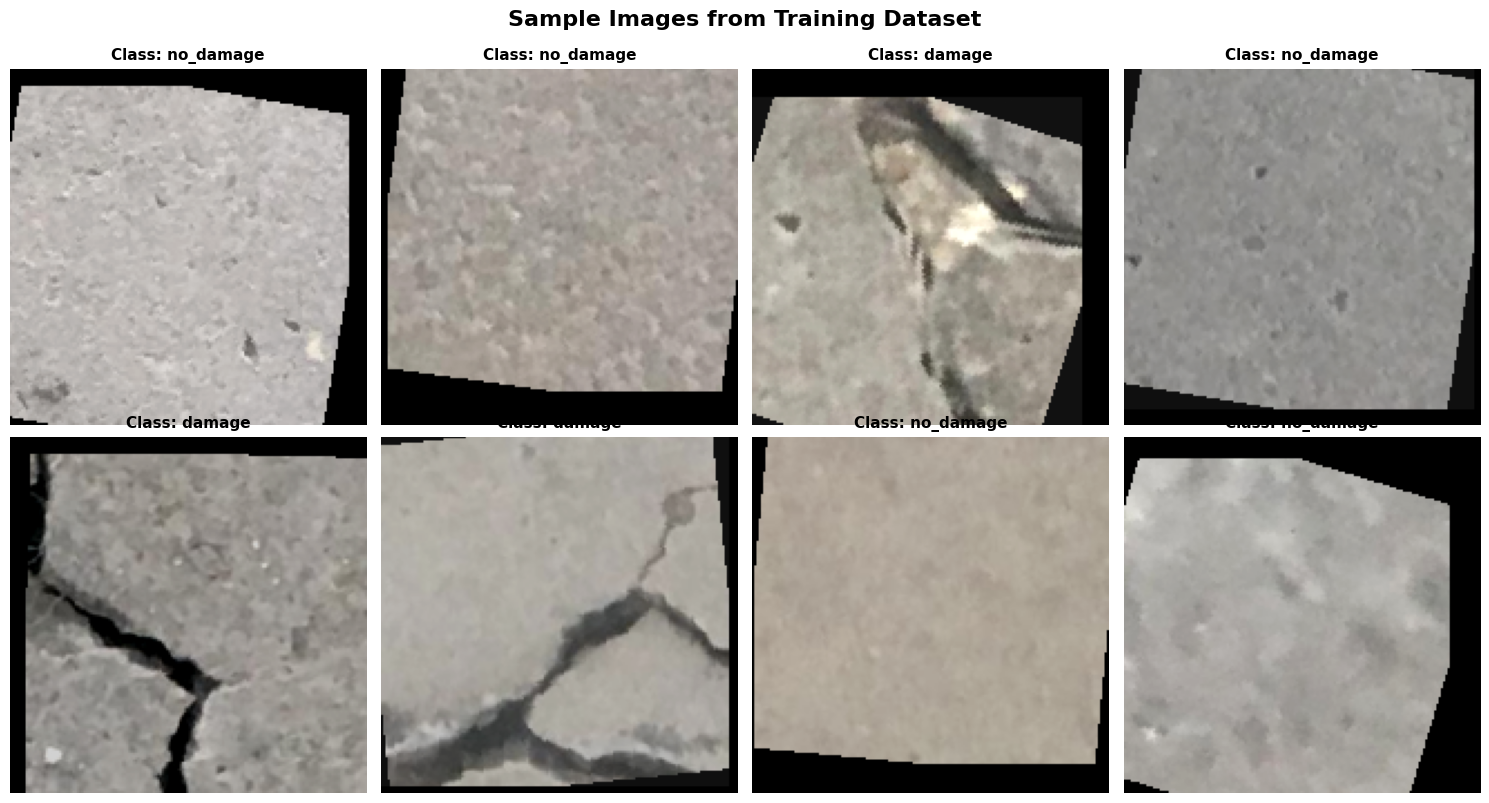

✓ Sample images displayed


In [13]:
# Denormalization for visualization
def denormalize(tensor):
    """Denormalize image tensor for visualization"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Get sample batch
images_batch, labels_batch = next(iter(train_loader))

# Display samples
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Sample Images from Training Dataset', fontsize=16, fontweight='bold', y=1.00)

for idx in range(8):
    ax = axes[idx // 4, idx % 4]
    img = denormalize(images_batch[idx])
    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    class_name = classes[labels_batch[idx].item()]
    ax.set_title(f'Class: {class_name}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Sample images displayed")

---
## Section 5: Model Architecture
Create ResNet50 with transfer learning: frozen backbone + custom classifier head.

In [14]:
def create_model(num_classes=2):
    """Create ResNet50 with custom classifier head"""
    
    # Load pretrained ResNet50
    model = models.resnet50(pretrained=True)
    print("✓ ResNet50 loaded with ImageNet weights")
    
    # Freeze backbone layers (transfer learning)
    for param in model.parameters():
        param.requires_grad = False
    print("✓ Backbone layers frozen")
    
    # Replace classification head with custom layers
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    print("✓ Custom classifier head added")
    
    # Unfreeze last layer of backbone for fine-tuning
    for param in model.layer4.parameters():
        param.requires_grad = True
    print("✓ Last backbone layer unfrozen for fine-tuning")
    
    return model

# Create model
print("\nCreating model...")
model = create_model(num_classes=len(classes))

# Calculate parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\n{'Model Statistics':^50}")
print(f"-" * 50)
print(f"Total Parameters:     {total_params:>20,}")
print(f"Trainable Parameters: {trainable_params:>20,}")
print(f"Frozen Parameters:    {frozen_params:>20,}")
print(f"-" * 50)


Creating model...


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\dipen/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:40<00:00, 2.51MB/s]


✓ ResNet50 loaded with ImageNet weights
✓ Backbone layers frozen
✓ Custom classifier head added
✓ Last backbone layer unfrozen for fine-tuning

                 Model Statistics                 
--------------------------------------------------
Total Parameters:               24,688,962
Trainable Parameters:           16,145,666
Frozen Parameters:               8,543,296
--------------------------------------------------


---
## Section 6: Training Loop Setup
Define training functions and early stopping mechanism.

In [15]:
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.best_epoch = 0
    
    def __call__(self, val_loss, epoch):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_epoch = epoch
        elif val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            self.best_epoch = epoch
        else:
            self.counter += 1
        
        return self.counter >= self.patience


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """Validate model on validation set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

print("✓ Training functions defined")

✓ Training functions defined


---
## Section 7: Model Training
Train the model with early stopping and learning rate scheduling.

In [16]:
def train_model(model, train_loader, val_loader, num_epochs=30):
    """Main training loop"""
    
    device = torch.device(CONFIG['device'])
    model = model.to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG['learning_rate']
    )
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
        verbose=False
    )
    
    early_stopping = EarlyStopping(patience=CONFIG['early_stopping_patience'])
    
    # Storage for history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    
    best_model_state = None
    best_val_acc = 0
    
    print(f"\nStarting training for {num_epochs} epochs on {device.type.upper()}...\n")
    print(f"{'Epoch':<8} {'Train Loss':<15} {'Train Acc':<15} {'Val Loss':<15} {'Val Acc':<15} {'Status':<20}")
    print("-" * 90)
    
    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_acc, _, _ = validate(
            model, val_loader, criterion, device
        )
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Determine status
        status = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            status = "✓ Best Model"
        
        print(f"{epoch+1:<8} {train_loss:<15.4f} {train_acc:<15.2f} {val_loss:<15.4f} {val_acc:<15.2f} {status:<20}")
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping
        if early_stopping(val_loss, epoch):
            print(f"\n✓ Early stopping triggered at epoch {epoch + 1}")
            print(f"  Best epoch: {early_stopping.best_epoch + 1}")
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history


# Train the model
model, history = train_model(
    model,
    train_loader,
    val_loader,
    num_epochs=CONFIG['epochs']
)

print("\n✓ Training complete!")


Starting training for 30 epochs on CUDA...

Epoch    Train Loss      Train Acc       Val Loss        Val Acc         Status              
------------------------------------------------------------------------------------------
1        0.0190          99.44           0.0034          99.87           ✓ Best Model        
2        0.0070          99.78           0.0025          99.92           ✓ Best Model        
3        0.0067          99.80           0.0026          99.92                               
4        0.0052          99.85           0.0025          99.91                               
5        0.0057          99.87           0.0023          99.94           ✓ Best Model        
6        0.0058          99.83           0.0084          99.67                               
7        0.0052          99.85           0.0020          99.95           ✓ Best Model        
8        0.0047          99.88           0.0021          99.95           ✓ Best Model        
9        0.0037   

---
## Section 8: Training History Visualization
Plot training vs validation loss and accuracy curves.

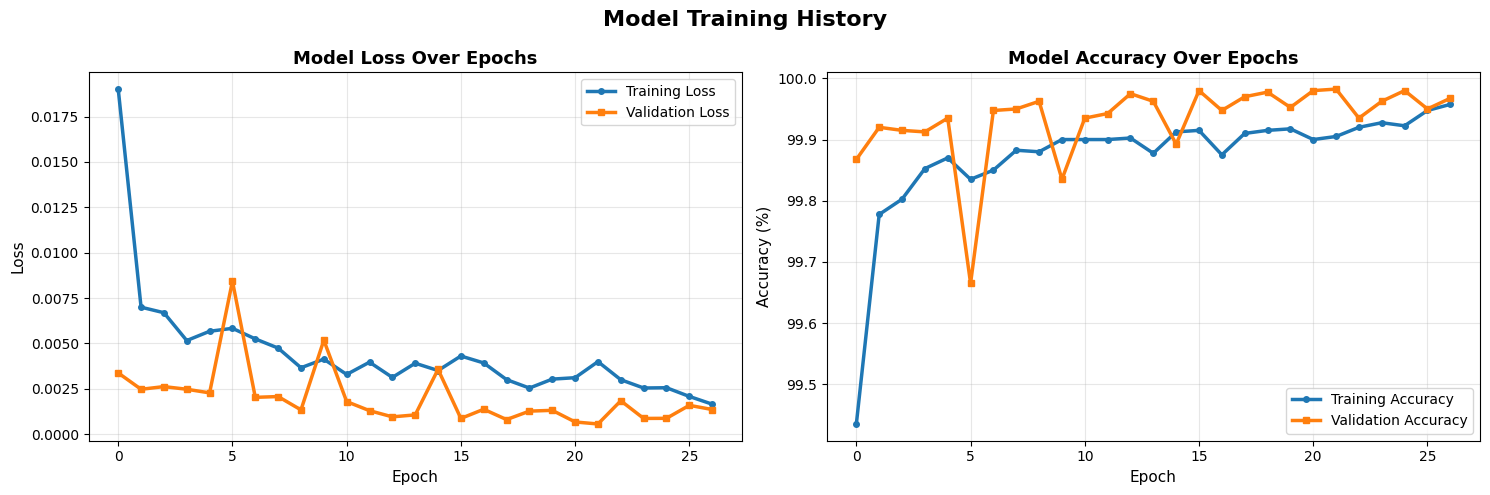


✓ Training history plots displayed


In [17]:
# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

# Loss plot
axes[0].plot(history['train_loss'], label='Training Loss', linewidth=2.5, marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2.5, marker='s', markersize=4)
axes[0].set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Training Accuracy', linewidth=2.5, marker='o', markersize=4)
axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].legend(fontsize=10, loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Training history plots displayed")

---
## Section 9: Model Evaluation
Evaluate the model on validation set and compute metrics.

In [18]:
def evaluate_model(model, val_loader, classes):
    """Evaluate model and generate metrics"""
    
    device = torch.device(CONFIG['device'])
    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return all_labels, all_preds

# Evaluate
print("Evaluating model on validation set...")
val_labels, val_preds = evaluate_model(model, val_loader, classes)

# Calculate metrics
accuracy = accuracy_score(val_labels, val_preds)
cm = confusion_matrix(val_labels, val_preds)

print(f"\n{'EVALUATION RESULTS':^50}")
print("=" * 50)
print(f"\nOverall Accuracy: {accuracy*100:.2f}%\n")

print("Confusion Matrix:")
print(cm)
print()

print("Classification Report:")
print(classification_report(val_labels, val_preds, target_names=classes))

Evaluating model on validation set...

                EVALUATION RESULTS                

Overall Accuracy: 99.97%

Confusion Matrix:
[[19987    13]
 [    0 20000]]

Classification Report:
              precision    recall  f1-score   support

      damage       1.00      1.00      1.00     20000
   no_damage       1.00      1.00      1.00     20000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



---
## Section 10: Confusion Matrix Visualization
Display confusion matrix as a heatmap.

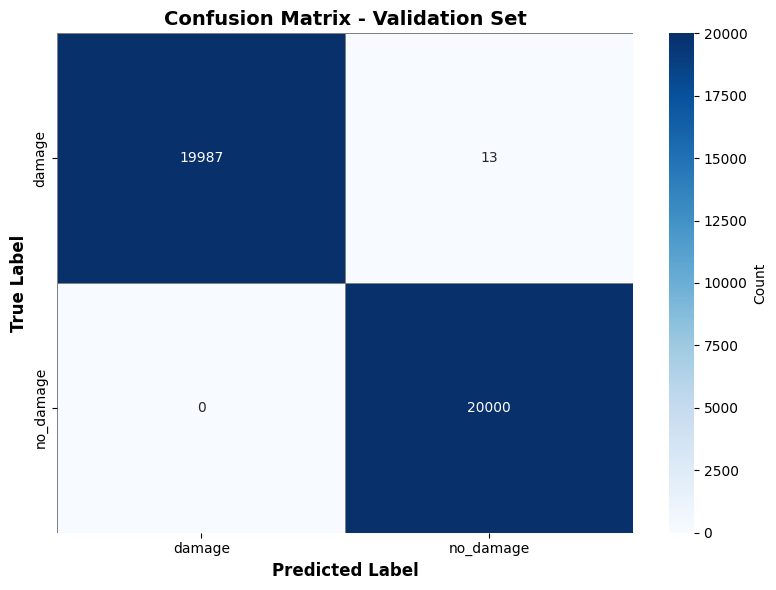

✓ Confusion matrix displayed


In [19]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, ax=ax, 
            linewidths=0.5, linecolor='gray')

ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Confusion matrix displayed")

---
## Section 11: Save Best Model
Save the trained model checkpoint for future use.

In [20]:
# Create directory if it doesn't exist
os.makedirs(os.path.dirname(CONFIG['model_save_path']), exist_ok=True)

# Save model
torch.save(model.state_dict(), CONFIG['model_save_path'])
print(f"✓ Model saved to: {CONFIG['model_save_path']}")

# Save model info
model_info = {
    'classes': classes,
    'image_size': CONFIG['image_size'],
    'accuracy': float(accuracy),
    'timestamp': datetime.now().isoformat(),
    'model_type': 'ResNet50',
    'total_params': sum(p.numel() for p in model.parameters()),
}

info_path = CONFIG['model_save_path'].replace('.pth', '_info.json')
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"✓ Model info saved to: {info_path}")

# Verify checkpoint
if os.path.exists(CONFIG['model_save_path']):
    model_size_mb = os.path.getsize(CONFIG['model_save_path']) / (1024 * 1024)
    print(f"✓ Model checkpoint verified: {model_size_mb:.2f} MB")
else:
    print("✗ Model save failed!")

✓ Model saved to: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\backend\saved_models\damage_detector_pytorch.pth
✓ Model info saved to: c:\Users\dipen\OneDrive\Desktop\BuildGuard-AI\backend\saved_models\damage_detector_pytorch_info.json
✓ Model checkpoint verified: 94.49 MB


---
## Section 12: Project Summary
Final summary of the project results and performance.

In [ ]:
print("\n" + "="*70)
print("PROJECT COMPLETION SUMMARY".center(70))
print("="*70)

print(f"\nDataset Information:")
print(f"  Training samples:           {len(train_dataset):,}")
print(f"  Validation samples:         {len(val_dataset):,}")
print(f"  Total samples:              {len(train_dataset) + len(val_dataset):,}")
print(f"  Number of classes:          {len(classes)}")
print(f"  Classes:                    {', '.join(classes)}")

print(f"\nModel Architecture:")
print(f"  Base model:                 ResNet50 (pretrained on ImageNet)")
print(f"  Transfer learning:          Yes (backbone frozen)")
print(f"  Fine-tuning:                Yes (layer4 unfrozen)")
print(f"  Custom classifier head:     512 → 256 → {len(classes)} neurons")
print(f"  Total parameters:           {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters:       {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

print(f"\nTraining Configuration:")
print(f"  Image size:                 {CONFIG['image_size']}×{CONFIG['image_size']}")
print(f"  Batch size:                 {CONFIG['batch_size']}")
print(f"  Epochs trained:             {len(history['train_loss'])}")
print(f"  Optimizer:                  Adam (lr={CONFIG['learning_rate']})")
print(f"  Loss function:              CrossEntropyLoss")
print(f"  Early stopping patience:    {CONFIG['early_stopping_patience']}")
print(f"  Device:                     {CONFIG['device'].upper()}")

print(f"\nPerformance Metrics:")
print(f"  Final validation accuracy:  {accuracy*100:.2f}%")
print(f"  Best training loss:         {min(history['train_loss']):.4f}")
print(f"  Best validation loss:       {min(history['val_loss']):.4f}")
print(f"  Best training accuracy:     {max(history['train_acc']):.2f}%")
print(f"  Best validation accuracy:   {max(history['val_acc']):.2f}%")

print(f"\nModel Checkpoint:")
print(f"  Path:                       {CONFIG['model_save_path']}")
print(f"  Size:                       {model_size_mb:.2f} MB")
print(f"  Status:                     ✓ Successfully saved")

print(f"\n" + "="*70)
print("Training Complete! Ready for Deployment ✓".center(70))
print("="*70)


                      PROJECT COMPLETION SUMMARY                      

Dataset Information:
  Training samples:           40,000
  Validation samples:         40,000
  Total samples:              80,000
  Number of classes:          2
  Classes:                    damage, no_damage

Model Architecture:
  Base model:                 ResNet50 (pretrained on ImageNet)
  Transfer learning:          Yes (backbone frozen)
  Fine-tuning:                Yes (layer4 unfrozen)
  Custom classifier head:     512 → 256 → 2 neurons
  Total parameters:           24,688,962
  Trainable parameters:       16,145,666

Training Configuration:
  Image size:                 160×160
  Batch size:                 64
  Epochs trained:             27
  Optimizer:                  Adam (lr=0.001)
  Loss function:              CrossEntropyLoss
  Early stopping patience:    5
  Device:                     CUDA

Performance Metrics:
  Final validation accuracy:  99.97%
  Best training loss:         0.0017
  Best 

: 